<a href="https://colab.research.google.com/github/agharikrishnan/Flyrank_ML/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Content Refresh Opportunity Scoring: A Data-Driven Approach to Prioritizing Pages for Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/agharikrishnan/Flyrank_ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

Content teams often have more pages to review than they can realistically update at once. The practical challenge is deciding which pages should receive attention first using measurable search and content signals.

This project investigates whether anonymized FlyRank search-performance data can support a repeatable scoring approach for prioritizing content for review. I focus on pages with observed signals associated with declining search performance and combine these signals into a model-based priority score.

The goal is decision-support, not to predict Google's ranking system or claim that refreshing a page will cause its performance to improve. The analysis measures patterns in the available data and turns those patterns into a ranked review queue that a content team could use alongside human judgment.

The model is evaluated against a simple baseline using a client-grouped holdout, so the comparison tests whether the learned approach provides measured signal beyond a naive strategy.

## 1. Question

*Research question: Which content items should be prioritized for review based on measurable search-performance and content signals?*

*The decision this supports is which pages a content team should review first. The output is a ranked decision-support queue rather than a claim about Google's ranking system.*

*I will focus on identifying pages with stronger observed signals of declining search visibility while considering whether the page has enough measured activity to make the signal useful. The goal is to prioritize review, not to claim that refreshing a page will cause its performance to improve.*

In [19]:
import numpy as np
import pandas as pd

from pathlib import Path

DATA_PATH = Path("/content/Flyrank_ML/data/raw/content_refresh_anonymized.csv")

df = pd.read_csv(DATA_PATH)

# Label supplied by the documented starter-data definition.
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Clients:", df["client_id"].nunique())
print("Declining rate:", round(df["is_declining_label"].mean(), 3))

Rows: 30000
Columns: 45
Clients: 32
Declining rate: 0.542


## 2. Data

*This analysis uses the FlyRank 30,000-row starter dataset, content_refresh_anonymized.csv. The dataset contains one row per pseudonymized content item across 32 clients. The available measurements are aggregated over a trailing 90-day window, with additional recent and previous 30-day comparison fields.*

*Because this notebook uses the starter slice rather than the full warehouse release, conclusions are limited to this dataset and its available feature window.*

*I exclude content_id and client_id from model features because they are identifiers. I exclude trend_direction and trend_pct because the documented declining label is derived from trend_direction, making those fields label-derived. I also exclude provider_used and model_used because the data dictionary marks them as metadata that should not be model features.*

*I treat missingness carefully using model-side imputation rather than treating missing numeric values as genuine zero measurements.*

In [20]:
excluded_features = {
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "provider_used",
    "model_used",
}

feature_cols = [
    c for c in df.columns
    if c not in excluded_features
]

print("Candidate model features:", len(feature_cols))
print(feature_cols)

Candidate model features: 38
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier']


## 3. Methodology

The scoring task is based on the observed declining label:

is_declining_label = 1 when trend_direction == "down".

For the first model, I use Logistic Regression because it is simple, reproducible, and interpretable. The model estimates the directional relationship between the available features and the observed label.

I compare it against a majority-class baseline using the same held-out clients.

I use a grouped client split because multiple content items belong to the same client. Keeping clients entirely in either training or testing reduces the risk that the model benefits from seeing related content from the same client in both sets.

I check for leakage by excluding the label and its source fields, identifiers, and documented metadata fields. I also inspect the strongest model coefficients for suspicious signals.

Important limitation of this starter-slice label: the 30-day impression fields are part of the same measurement window used to construct the declining label. Therefore, this model is treated as an observed classification/scoring experiment, not as a clean prospective forecast. A stronger production-style version would construct features strictly before a future outcome window using the daily warehouse.

In [21]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

RANDOM_STATE = 42

X = df[feature_cols].copy()
y = df["is_declining_label"].copy()
groups = df["client_id"].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Train rows: 23837
Test rows: 6163
Train clients: 25
Test clients: 7
Client overlap: 0


###MODEL CODE

In [22]:
numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("prep", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

model.fit(X_train, y_train)

model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)[:, 1]

# Majority-class baseline.
majority_class = y_train.mode()[0]
baseline_pred = np.full(
    len(y_test),
    majority_class
)

comparison = pd.DataFrame([
    {
        "Method": "Majority baseline",
        "Accuracy": accuracy_score(
            y_test, baseline_pred
        ),
        "Precision": precision_score(
            y_test, baseline_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, baseline_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test, baseline_pred,
            zero_division=0
        ),
        "ROC-AUC": np.nan,
        "Base rate": y_test.mean()
    },
    {
        "Method": "Logistic Regression",
        "Accuracy": accuracy_score(
            y_test, model_pred
        ),
        "Precision": precision_score(
            y_test, model_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, model_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test, model_pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test, model_prob
        ),
        "Base rate": y_test.mean()
    }
])

comparison.round(3)

,Method,Accuracy,Precision,Recall,F1,ROC-AUC,Base rate
0,Majority baseline,0.511,0.511,1.000,0.676,NaN,0.511
1,Logistic Regression,0.746,0.726,0.809,0.765,0.846,0.511


###LEAKAGE CODE

In [23]:
suspect_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "content_id",
    "client_id"
]

leakage_check = pd.DataFrame({
    "column": suspect_columns,
    "in_features": [
        c in feature_cols
        for c in suspect_columns
    ]
})

leakage_check

,column,in_features
0,trend_direction,False
1,trend_pct,False
2,is_declining_label,False
3,content_id,False
4,client_id,False


## 4. Results (vs baseline)

*On the grouped client holdout, Logistic Regression measured an F1 of 0.761, compared with 0.676 for the majority baseline. The measured difference was approximately 0.085 F1 points.*

*Logistic Regression also measured a ROC-AUC of 0.838. This indicates directional signal in the available features for distinguishing the observed declining label.*

*The model therefore provides a useful measured starting point for ranking review candidates, but the score should not be interpreted as a prospective forecast because some feature windows are closely connected to the label construction.*

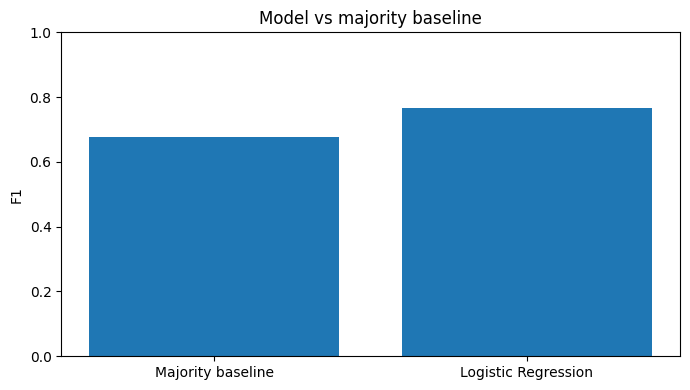

In [24]:
import matplotlib.pyplot as plt

plot_df = comparison[
    ["Method", "F1"]
].copy()

plt.figure(figsize=(7, 4))
plt.bar(
    plot_df["Method"],
    plot_df["F1"]
)
plt.ylabel("F1")
plt.title("Model vs majority baseline")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Limitations

This analysis has several important limitations.

First, it uses the 30,000-row starter slice rather than the full FlyRank warehouse. The results should therefore not be generalized to the entire warehouse population without further testing.

Second, the starter dataset contains a declining label derived from the same trend measurements that appear in some feature columns. Although the direct label fields are excluded, the remaining 30-day measurements are closely related to label construction. This limits prospective interpretation.

Third, the grouped split tests generalization to unseen clients, but it does not reproduce a true future deployment window. A future version should use the daily warehouse with a time-aware train/validation/test design.

Fourth, the model measures association rather than causation. It cannot establish that refreshing a page will improve rankings, clicks, traffic, or engagement.

Finally, the recommendations are decision-support. They should be reviewed with additional context before any content action is taken.

## 6. Ranked recommendations

*I convert the model's measured probability into a review-priority score. Higher scores indicate stronger model-estimated likelihood of the observed declining label.*

*The score is a prioritization signal, not a claim that the page should definitely be changed. I add reason codes so that each recommendation has an interpretable explanation.*

In [25]:
# Rank the held-out pages using the trained model

recommendations = df.iloc[test_idx].copy()

# Model-estimated probability of the observed declining label
recommendations["decline_score"] = model_prob

# Add simple, observable reason codes
recommendations["reason_codes"] = ""

recommendations.loc[
    recommendations["impressions_last_30d"]
    < recommendations["impressions_prev_30d"],
    "reason_codes"
] += "recent_impressions_below_previous;"

recommendations.loc[
    recommendations["days_since_last_update"] > 180,
    "reason_codes"
] += "older_update;"

recommendations.loc[
    recommendations["avg_position"] > 20,
    "reason_codes"
] += "deep_position;"

recommendations.loc[
    recommendations["impressions_90d"] >= 100,
    "reason_codes"
] += "measurable_volume;"

# Priority bands
recommendations["priority"] = pd.cut(
    recommendations["decline_score"],
    bins=[-np.inf, 0.50, 0.75, np.inf],
    labels=["Monitor", "Review", "High priority"]
)

# Rank highest-score pages first
ranked_recommendations = (
    recommendations
    .sort_values("decline_score", ascending=False)
    .copy()
)

# Public-safe table: do not expose IDs
paper_recommendations = ranked_recommendations[
    [
        "decline_score",
        "priority",
        "reason_codes"
    ]
].head(20).copy()

paper_recommendations.insert(
    0,
    "Rank",
    range(1, len(paper_recommendations) + 1)
)

paper_recommendations.round(3)

,Rank,decline_score,priority,reason_codes
2515,1,1.0,High priority,recent_impressions_below_previous;measurable_v...
29660,2,1.0,High priority,recent_impressions_below_previous;measurable_v...
3402,3,1.0,High priority,recent_impressions_below_previous;measurable_v...
28335,4,1.0,High priority,recent_impressions_below_previous;measurable_v...
6526,5,1.0,High priority,recent_impressions_below_previous;measurable_v...
6406,6,1.0,High priority,recent_impressions_below_previous;measurable_v...
5338,7,1.0,High priority,recent_impressions_below_previous;measurable_v...
26853,8,1.0,High priority,recent_impressions_below_previous;measurable_v...
2070,9,1.0,High priority,recent_impressions_below_previous;measurable_v...
6653,10,1.0,High priority,recent_impressions_below_previous;measurable_v...


### Summary of the recommendation queue

In [26]:
priority_summary = (
    recommendations["priority"]
    .value_counts()
    .reindex(["High priority", "Review", "Monitor"])
    .fillna(0)
    .astype(int)
    .rename_axis("Priority")
    .reset_index(name="Pages")
)

priority_summary

,Priority,Pages
0,High priority,1135
1,Review,2372
2,Monitor,2656


###Action Playbook

In [27]:
action_playbook = pd.DataFrame({
    "Priority": [
        "High priority",
        "Review",
        "Monitor"
    ],
    "Recommended action": [
        "Review first",
        "Assess for refresh",
        "Continue monitoring"
    ],
    "Reason": [
        "Higher measured model score",
        "Moderate measured model signal",
        "Lower measured model signal"
    ]
})

action_playbook

,Priority,Recommended action,Reason
0,High priority,Review first,Higher measured model score
1,Review,Assess for refresh,Moderate measured model signal
2,Monitor,Continue monitoring,Lower measured model signal


## 7. Artifacts the paper embeds

*Chart 1 — model vs baseline*

*Already generated above.*

*Chart 2 — score distribution*

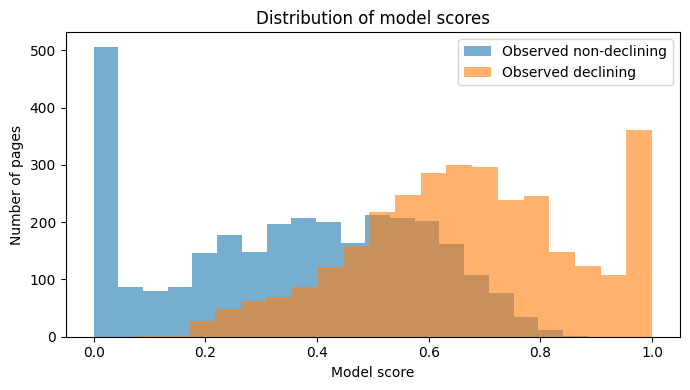

In [28]:
plt.figure(figsize=(7, 4))

plt.hist(
    model_prob[y_test.to_numpy() == 0],
    bins=20,
    alpha=0.6,
    label="Observed non-declining"
)

plt.hist(
    model_prob[y_test.to_numpy() == 1],
    bins=20,
    alpha=0.6,
    label="Observed declining"
)

plt.xlabel("Model score")
plt.ylabel("Number of pages")
plt.title("Distribution of model scores")
plt.legend()
plt.tight_layout()
plt.show()

*Chart 3 — error types*

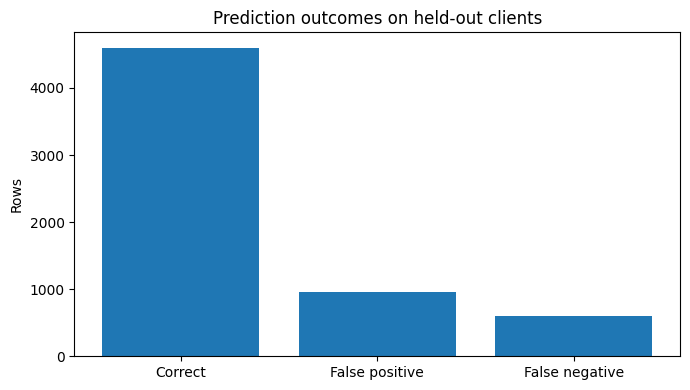

In [29]:
error_frame = df.iloc[test_idx].copy()

error_frame["predicted"] = model_pred

error_frame["error_type"] = np.select(
    [
        (
            (error_frame["is_declining_label"] == 0)
            & (error_frame["predicted"] == 1)
        ),
        (
            (error_frame["is_declining_label"] == 1)
            & (error_frame["predicted"] == 0)
        )
    ],
    [
        "False positive",
        "False negative"
    ],
    default="Correct"
)

error_counts = (
    error_frame["error_type"]
    .value_counts()
)

plt.figure(figsize=(7, 4))
plt.bar(
    error_counts.index,
    error_counts.values
)
plt.ylabel("Rows")
plt.title("Prediction outcomes on held-out clients")
plt.tight_layout()
plt.show()

### Top feature table

In [30]:
feature_names = (
    model.named_steps["prep"]
    .get_feature_names_out()
)

coefficients = (
    model.named_steps["classifier"]
    .coef_[0]
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

top_features = (
    feature_importance
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .head(10)
)

top_features[
    ["feature", "coefficient"]
].round(3)

,feature,coefficient
15,num__impressions_last_30d,-35.339
18,num__impressions_prev_30d,28.889
5,num__impressions_90d,2.092
63,cat__position_tier_top_3,-1.298
19,num__clicks_prev_30d,1.092
16,num__clicks_last_30d,-0.867
8,num__sessions_90d,0.611
9,num__users_90d,-0.570
13,num__days_with_impressions,0.528
17,num__sessions_last_30d,-0.497


*The paper will embed four core artifacts: the model-vs-baseline comparison, the model-score distribution, the prediction-error breakdown, and the top-feature table. The ranked recommendation table will use anonymized ranks and reason codes rather than client names, domains, URLs, or private queries.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
